### COMP 333 - Programming Assignment 4

Annika Timermanis

ID: 40131128

**Assignment Description:** Combining data analysis techniques learned in class, in order to assess the Titanic dataset to determine which factors/features most-impacted the survival  rate of child passengers (passengers under the age of 18). We are to present our findings through data story telling & visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
df = pd.read_csv('/content/gdrive/My Drive/Colab Notebooks/comp 333 labs/prog_assignments/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Variables:**

1. PassengerId = Passenger number

2. Survived = If they survived or not (0 = died, 1 = alive)

3. Pclass = Ticket class (1 = First class 2 = Second class 3 = Third class), Proxy for socio-economic class

4. Name = Name of passenger

5. Sex	= Gender of passenger (male, female)

6. Age	= Age of passenger

7. SibSp	= Number of siblings

8. Parch	= Number of Parents/Children Aboard

9. Ticket = Ticket number

10. Fare = Cost of ticket

11. Cabin = Cabin

12. Embarked = Port of Embarkation (C = Cherbourg; Q = Queenstown; S = Southampton)

### **For the purpose of the analysis, children will be defined as passengers under the age of 18**

In [3]:
df.shape

(891, 12)

In [4]:
df_child = df.loc[(df['Age'] < 18)]

In [5]:
df_child.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
14,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
22,23,1,3,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q
24,25,0,3,"Palsson, Miss. Torborg Danira",female,8.0,3,1,349909,21.0750,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C
43,44,1,2,"Laroche, Miss. Simonne Marie Anne Andree",female,3.0,1,2,SC/Paris 2123,41.5792,NaN,C
50,51,0,3,"Panula, Master. Juha Niilo",male,7.0,4,1,3101295,39.6875,NaN,S


### **Out of 891 observations (people), only 113 were under the age of 18**

In [6]:
df_child.shape

(113, 12)

In [7]:
df_child.isnull().sum()

PassengerId     0
Survived        0
Pclass          0
Name            0
Sex             0
Age             0
SibSp           0
Parch           0
Ticket          0
Fare            0
Cabin          94
Embarked        0
dtype: int64

In [8]:
print("Max age: ", df_child['Age'].max())
print("Min age: ", df_child['Age'].min())

Max age:  17.0
Min age:  0.42


In [9]:
print(sorted(df_child['Age'].unique()))

[0.42, 0.67, 0.75, 0.83, 0.92, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 14.5, 15.0, 16.0, 17.0]


In [10]:
df_child['Age'].value_counts()

16.00    17
17.00    13
2.00     10
4.00     10
9.00      8
1.00      7
3.00      6
14.00     6
15.00     5
11.00     4
5.00      4
8.00      4
6.00      3
7.00      3
10.00     2
0.75      2
13.00     2
0.83      2
0.92      1
12.00     1
14.50     1
0.67      1
0.42      1
Name: Age, dtype: int64

### **Boys to Girls ratio**

3 more boys than girls

---



In [11]:
df_child['Sex'].value_counts()

male      58
female    55
Name: Sex, dtype: int64

### **Survived to Didn't Survive ratio**

9 more survivors than non-survivors

---



In [12]:
df_child['Survived'].value_counts()

1    61
0    52
Name: Survived, dtype: int64

### **I will analyze features:**

*   PClass
*   Sex
*   Age
*   SibSp
*   Parch
*   Fare
*   Embarked




In [13]:
df_child_survived = df_child[df_child['Survived'] == 1]
df_child_died = df_child[df_child['Survived'] == 0]

print(df_child_survived.shape)
print(df_child_died.shape)

(61, 12)
(52, 12)


### **DF to hold all observations of children passengers who survived**

In [14]:
df_child_survived.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
22,23,1,3,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C
43,44,1,2,"Laroche, Miss. Simonne Marie Anne Andree",female,3.0,1,2,SC/Paris 2123,41.5792,NaN,C


### **DF to hold all observations of children passengers who didn't survive**

In [15]:
df_child_died.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
14,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
24,25,0,3,"Palsson, Miss. Torborg Danira",female,8.0,3,1,349909,21.0750,NaN,S
50,51,0,3,"Panula, Master. Juha Niilo",male,7.0,4,1,3101295,39.6875,NaN,S


# **Analysis of Survivors**

### **61 children survived**

In [16]:
df_child_survived['Survived'].value_counts()

1    61
Name: Survived, dtype: int64

### **52 children died**

In [17]:
df_child_died['Survived'].value_counts()

0    52
Name: Survived, dtype: int64

### **Having a higher Pclass could suggest higher chance of survival**

A high number of survivors came from pclass 3, however out of 78 children from pclass 3, only 29 survived while 49 died. In contrast, out of 23 children in pclass 2, 21 of them survived, and out of 12 children from pclass 1, 11 of them survived, which could suggest that having a higher socioeconomic class (1 or 2) increased chance of survival.

---



In [18]:
df_child_survived['Pclass'].value_counts()

3    29
2    21
1    11
Name: Pclass, dtype: int64

In [19]:
df_child_died['Pclass'].value_counts()

3    49
2     2
1     1
Name: Pclass, dtype: int64

In [20]:
df_child['Pclass'].value_counts()

3    78
2    23
1    12
Name: Pclass, dtype: int64

In [21]:
pclass_percentages_survived = df_child_survived['Pclass'].value_counts()/df_child['Pclass'].value_counts()
print(pclass_percentages_survived)

3    0.371795
2    0.913043
1    0.916667
Name: Pclass, dtype: float64


In [22]:
pclass_percentages_died = df_child_died['Pclass'].value_counts()/df_child['Pclass'].value_counts()
print(pclass_percentages_died)

3    0.628205
2    0.086957
1    0.083333
Name: Pclass, dtype: float64


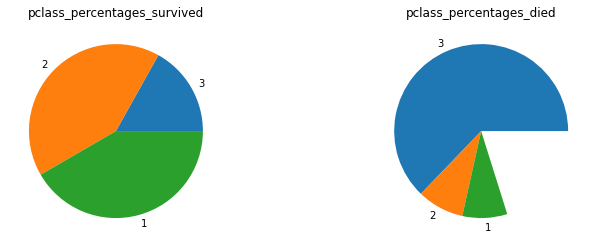

In [23]:
fig, axes = plt.subplots(1, 2)
fig.set_size_inches(12,4)
axes[0].pie(pclass_percentages_survived,labels = pclass_percentages_survived.index)
axes[0].set_title('pclass_percentages_survived');
axes[1].pie(pclass_percentages_died,labels = pclass_percentages_died.index)
axes[1].set_title('pclass_percentages_died');

### **Being female could suggest higher chance of survival**
 
There were 3 more boys than girls in total, and 15 more girls survived than boys, so it might suggest that girls had an increased chance at survival.


---



In [24]:
df_child_survived['Sex'].value_counts()

female    38
male      23
Name: Sex, dtype: int64

In [25]:
df_child_died['Sex'].value_counts()

male      35
female    17
Name: Sex, dtype: int64

In [26]:
df_child['Sex'].value_counts()

male      58
female    55
Name: Sex, dtype: int64

In [27]:
sex_percentages_survived = df_child_survived['Sex'].value_counts()/df_child['Sex'].value_counts()
print(sex_percentages_survived)

female    0.690909
male      0.396552
Name: Sex, dtype: float64


In [28]:
sex_percentages_died = df_child_died['Sex'].value_counts()/df_child['Sex'].value_counts()
print(sex_percentages_died)

male      0.603448
female    0.309091
Name: Sex, dtype: float64


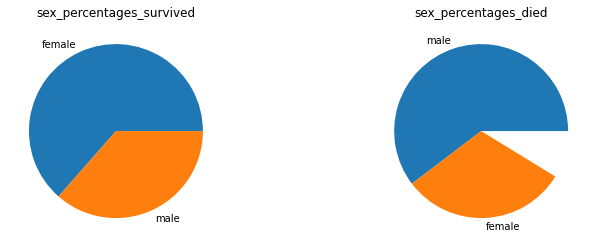

In [29]:
fig, axes = plt.subplots(1, 2)
fig.set_size_inches(12,4)
axes[0].pie(sex_percentages_survived,labels = sex_percentages_survived.index)
axes[0].set_title('sex_percentages_survived');
axes[1].pie(sex_percentages_died,labels = sex_percentages_died.index)
axes[1].set_title('sex_percentages_died');

### **Being under 6 years old could suggest higher chance of survival**

Ages of both survivors and non-survivors peaked around older children, however out of the 113 child passengers, 44 were under 6 years old, out of those 44, 31 of them survived.


---



In [30]:
print("Num of children who survived and were under 6 years old: ",df_child_survived['Age'].loc[(df_child_survived['Age'] < 6)].value_counts().sum())
print(df_child_survived['Age'].loc[(df_child_survived['Age'] < 6)].value_counts())

Num of children who survived and were under 6 years old:  31
4.00    7
3.00    5
1.00    5
5.00    4
2.00    3
0.83    2
0.75    2
0.92    1
0.67    1
0.42    1
Name: Age, dtype: int64


In [31]:
print("Num of children who died and were under 6 years old: ", df_child_died['Age'].loc[(df_child_died['Age'] < 6)].value_counts().sum())
print(df_child_died['Age'].loc[(df_child_died['Age'] < 6)].value_counts())

Num of children who died and were under 6 years old:  13
2.0    7
4.0    3
1.0    2
3.0    1
Name: Age, dtype: int64


In [32]:
print("Num of children on board who were under 6 years old: ",df_child['Age'].loc[(df_child['Age'] < 6)].value_counts().sum())
print(df_child['Age'].loc[(df_child['Age'] < 6)].value_counts())

Num of children on board who were under 6 years old:  44
2.00    10
4.00    10
1.00     7
3.00     6
5.00     4
0.83     2
0.75     2
0.92     1
0.67     1
0.42     1
Name: Age, dtype: int64


In [33]:
df_child_survived['Age'].mode()

0    4.0
dtype: float64

In [34]:
df_child_died['Age'].mode()

0    16.0
dtype: float64

In [35]:
df_child_survived['Age'].describe()

count    61.000000
mean      7.888033
std       6.129831
min       0.420000
25%       3.000000
50%       5.000000
75%      15.000000
max      17.000000
Name: Age, dtype: float64

### **Having over 3 siblings could suggest lower chance of survival**
Out of all children on board, 23 had over 3 siblings on board, of those 23, 20 of them died where as 3 survived.


---



In [36]:
print("Num of children who survived and had over 3 siblings on board: ",df_child_survived['SibSp'].loc[(df_child_survived['SibSp'] > 3)].value_counts().sum())
print(df_child_survived['SibSp'].loc[(df_child_survived['SibSp'] > 3)].value_counts())

Num of children who survived and had over 3 siblings on board:  3
4    3
Name: SibSp, dtype: int64


In [37]:
print("Num of children who died and had over 3 siblings on board: ",df_child_died['SibSp'].loc[(df_child_died['SibSp'] > 3)].value_counts().sum())
print(df_child_died['SibSp'].loc[(df_child_died['SibSp'] > 3)].value_counts())

Num of children who died and had over 3 siblings on board:  20
4    15
5     5
Name: SibSp, dtype: int64


In [38]:
print("Num of children on board who had over 3 siblings on board: ",df_child['SibSp'].loc[(df_child['SibSp'] > 3)].value_counts().sum())
print(df_child['SibSp'].loc[(df_child['SibSp'] > 3)].value_counts())

Num of children on board who had over 3 siblings on board:  23
4    18
5     5
Name: SibSp, dtype: int64


In [39]:
df_child_survived['SibSp'].value_counts()

0    28
1    25
2     5
4     3
Name: SibSp, dtype: int64

In [40]:
df_child_died['SibSp'].value_counts()

0    15
4    15
1     8
3     7
5     5
2     2
Name: SibSp, dtype: int64

### **Number of parents/children on board did not seem to affect chance of survival**
Having one parent on board was the most frequent for children who survived, but comparing with overall number it did not provide much insight.


---



In [41]:
df_child_survived['Parch'].value_counts()

1    27
2    18
0    16
Name: Parch, dtype: int64

In [42]:
df_child_died['Parch'].value_counts()

2    18
1    17
0    16
3     1
Name: Parch, dtype: int64

### **Paying over $50 could suggest higher chance of survival**
Overall, most children paid a low fare, however out of the 11 children who did pay for a fare over \$50, 10 of them survived, and only 1 died.


---



In [43]:
print("Num of children who survived and paid over $50: ",df_child_survived['Fare'].loc[(df_child_survived['Fare'] > 50)].value_counts().sum())
print(df_child_survived['Fare'].loc[(df_child_survived['Fare'] > 50)].value_counts())

Num of children who survived and paid over $50:  10
120.0000    2
151.5500    1
108.9000    1
57.9792     1
81.8583     1
86.5000     1
110.8833    1
211.3375    1
57.0000     1
Name: Fare, dtype: int64


In [44]:
print("Num of children who died and paid over $50: ",df_child_died['Fare'].loc[(df_child_died['Fare'] > 50)].value_counts().sum())
print(df_child_died['Fare'].loc[(df_child_died['Fare'] > 50)].value_counts())

Num of children who died and paid over $50:  1
151.55    1
Name: Fare, dtype: int64


In [45]:
print("Num of children on board who  paid over $50: ",df_child['Fare'].loc[(df_child['Fare'] > 50)].value_counts().sum())
print(df_child['Fare'].loc[(df_child['Fare'] > 50)].value_counts())

Num of children on board who  paid over $50:  11
151.5500    2
120.0000    2
108.9000    1
57.9792     1
81.8583     1
86.5000     1
110.8833    1
211.3375    1
57.0000     1
Name: Fare, dtype: int64


### **Embarking from port C could suggest higher chance of survival**
24 children embarked from port C (Cherbourg), of those 24, 18 of them survived, and 6 died.

---



In [46]:
df_child_survived['Embarked'].value_counts()

S    40
C    18
Q     3
Name: Embarked, dtype: int64

In [47]:
df_child_died['Embarked'].value_counts()

S    42
C     6
Q     4
Name: Embarked, dtype: int64

In [48]:
df_child['Embarked'].value_counts()

S    82
C    24
Q     7
Name: Embarked, dtype: int64

In [49]:
embarked_percentages_survived = df_child_survived['Embarked'].value_counts()/df_child['Embarked'].value_counts()
print(embarked_percentages_survived)

S    0.487805
C    0.750000
Q    0.428571
Name: Embarked, dtype: float64


In [50]:
embarked_percentages_died = df_child_died['Embarked'].value_counts()/df_child['Embarked'].value_counts()
print(embarked_percentages_died)

S    0.512195
C    0.250000
Q    0.571429
Name: Embarked, dtype: float64


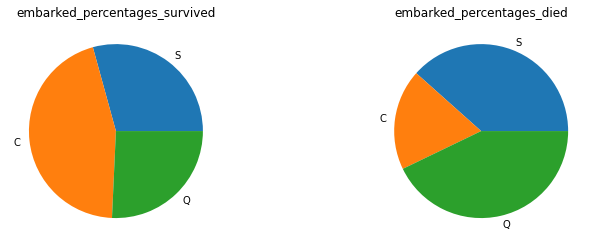

In [51]:
fig, axes = plt.subplots(1, 2)
fig.set_size_inches(12,4)
axes[0].pie(embarked_percentages_survived,labels = embarked_percentages_survived.index)
axes[0].set_title('embarked_percentages_survived');
axes[1].pie(embarked_percentages_died,labels = embarked_percentages_died.index)
axes[1].set_title('embarked_percentages_died');

# **Visualizing the Results**

### **Histogram of PClass**

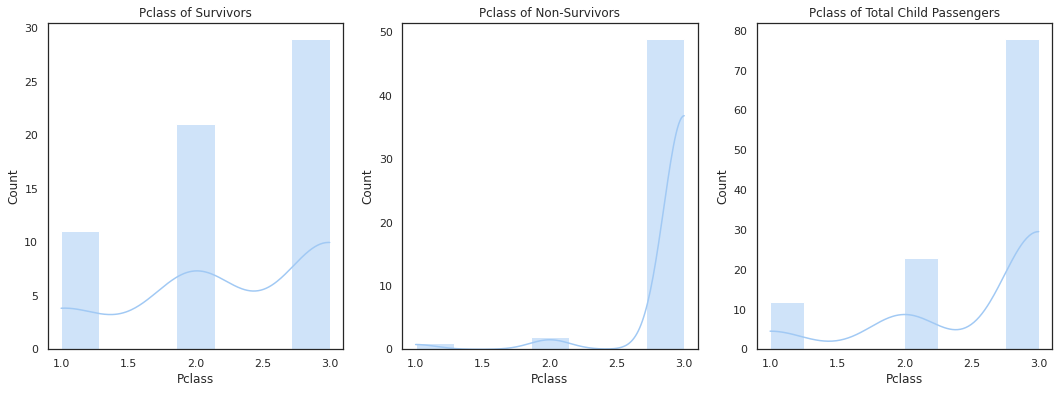

In [52]:
sns.set_theme(palette="pastel",style="white")
fig, axes = plt.subplots(1, 3)
fig.set_size_inches(18,6)
sns.histplot(df_child_survived['Pclass'],kde=True,ax=axes[0]).set_title("Pclass of Survivors");
sns.histplot(df_child_died['Pclass'],kde=True,ax=axes[1]).set_title("Pclass of Non-Survivors");
sns.histplot(df_child['Pclass'],kde=True,ax=axes[2]).set_title("Pclass of Total Child Passengers");

### **Histogram of Sex**

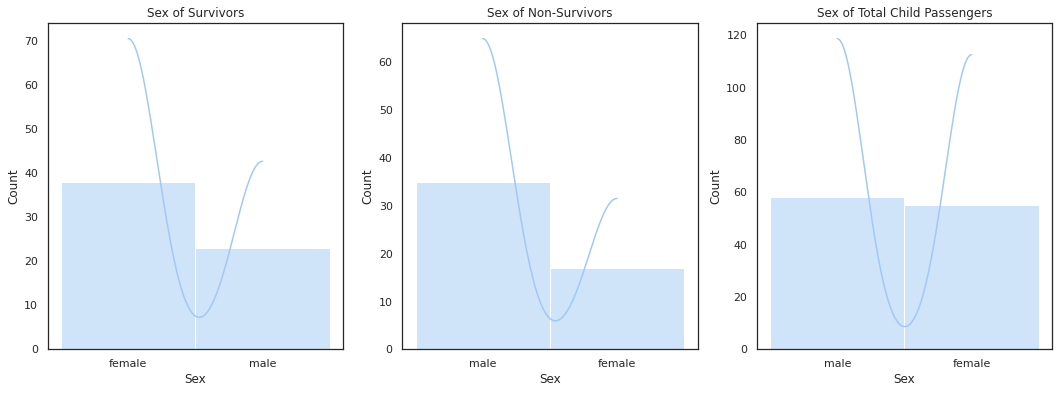

In [53]:
sns.set_theme(palette="pastel",style="white")
fig, axes = plt.subplots(1, 3)
fig.set_size_inches(18,6)
sns.histplot(df_child_survived['Sex'],kde=True,ax=axes[0]).set_title("Sex of Survivors");
sns.histplot(df_child_died['Sex'],kde=True,ax=axes[1]).set_title("Sex of Non-Survivors");
sns.histplot(df_child['Sex'],kde=True,ax=axes[2]).set_title("Sex of Total Child Passengers");

### **Histogram of Age**

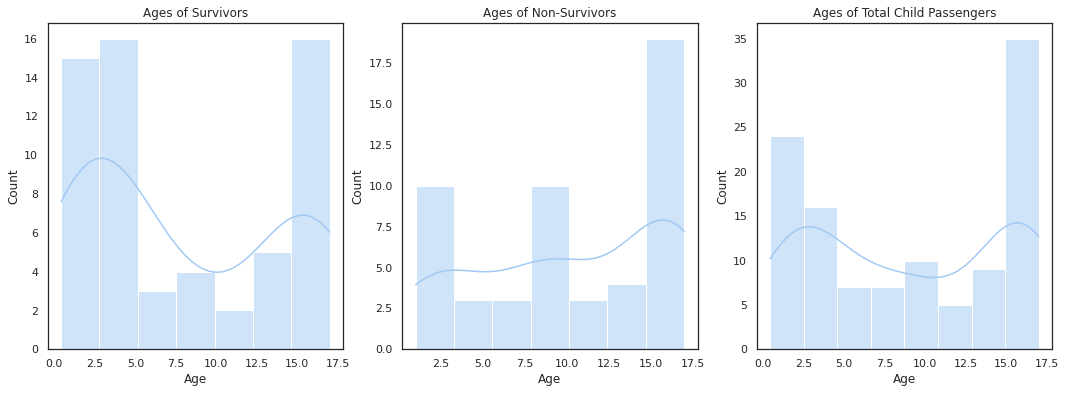

In [54]:
sns.set_theme(palette="pastel",style="white")
fig, axes = plt.subplots(1, 3)
fig.set_size_inches(18,6)
sns.histplot(df_child_survived['Age'],kde=True,ax=axes[0]).set_title("Ages of Survivors");
sns.histplot(df_child_died['Age'],kde=True,ax=axes[1]).set_title("Ages of Non-Survivors");
sns.histplot(df_child['Age'],kde=True,ax=axes[2]).set_title("Ages of Total Child Passengers");

### **Histogram of Number of Siblings on Board**

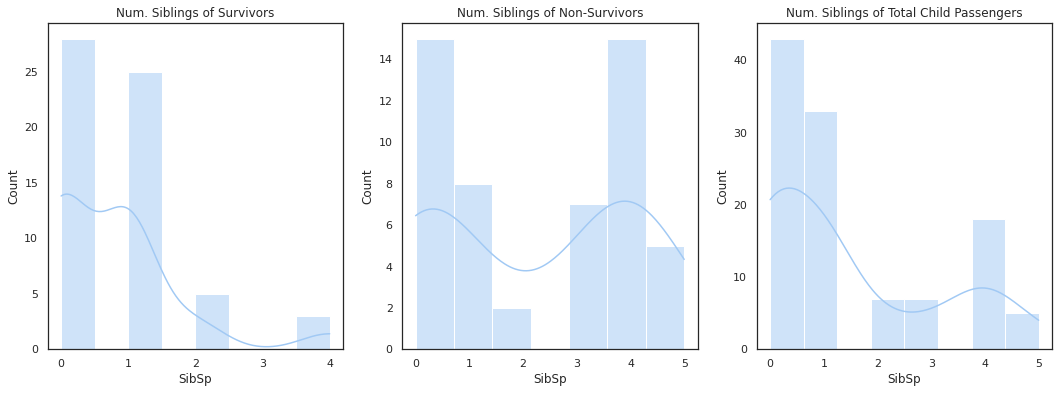

In [55]:
sns.set_theme(palette="pastel",style="white")
fig, axes = plt.subplots(1, 3)
fig.set_size_inches(18,6)
sns.histplot(df_child_survived['SibSp'],kde=True,ax=axes[0]).set_title("Num. Siblings of Survivors");
sns.histplot(df_child_died['SibSp'],kde=True,ax=axes[1]).set_title("Num. Siblings of Non-Survivors");
sns.histplot(df_child['SibSp'],kde=True,ax=axes[2]).set_title("Num. Siblings of Total Child Passengers");

### **Histogram of Number of Parents or Children on Board**

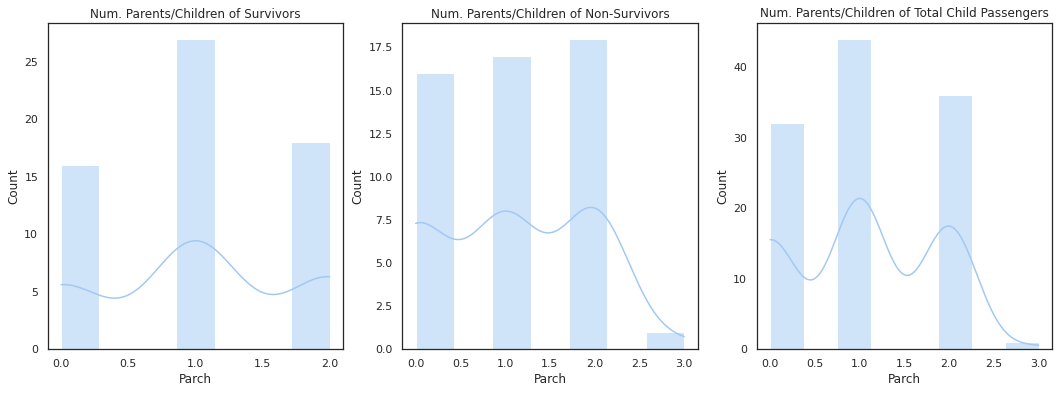

In [56]:
sns.set_theme(palette="pastel",style="white")
fig, axes = plt.subplots(1, 3)
fig.set_size_inches(18,6)
sns.histplot(df_child_survived['Parch'],kde=True,ax=axes[0]).set_title("Num. Parents/Children of Survivors");
sns.histplot(df_child_died['Parch'],kde=True,ax=axes[1]).set_title("Num. Parents/Children of Non-Survivors");
sns.histplot(df_child['Parch'],kde=True,ax=axes[2]).set_title("Num. Parents/Children of Total Child Passengers");

### **Histogram of Fare**

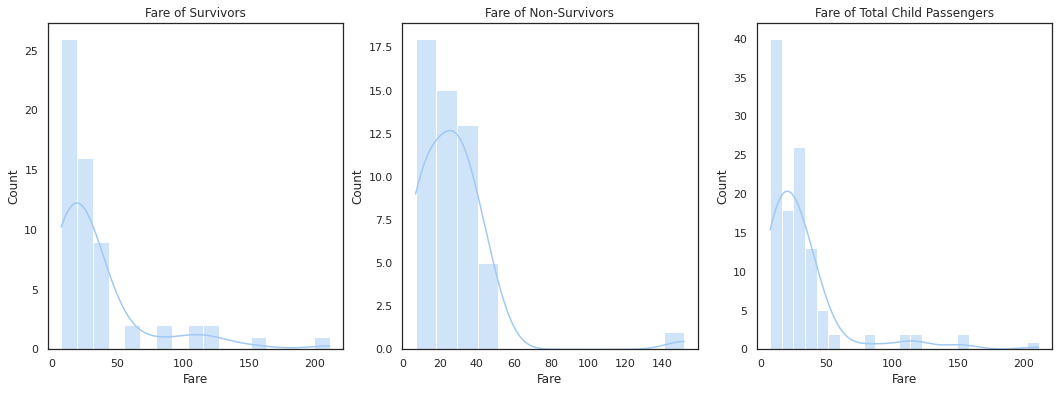

In [57]:
sns.set_theme(palette="pastel",style="white")
fig, axes = plt.subplots(1, 3)
fig.set_size_inches(18,6)
sns.histplot(df_child_survived['Fare'],kde=True,ax=axes[0]).set_title("Fare of Survivors");
sns.histplot(df_child_died['Fare'],kde=True,ax=axes[1]).set_title("Fare of Non-Survivors");
sns.histplot(df_child['Fare'],kde=True,ax=axes[2]).set_title("Fare of Total Child Passengers");

### **Histogram of Embarkation**

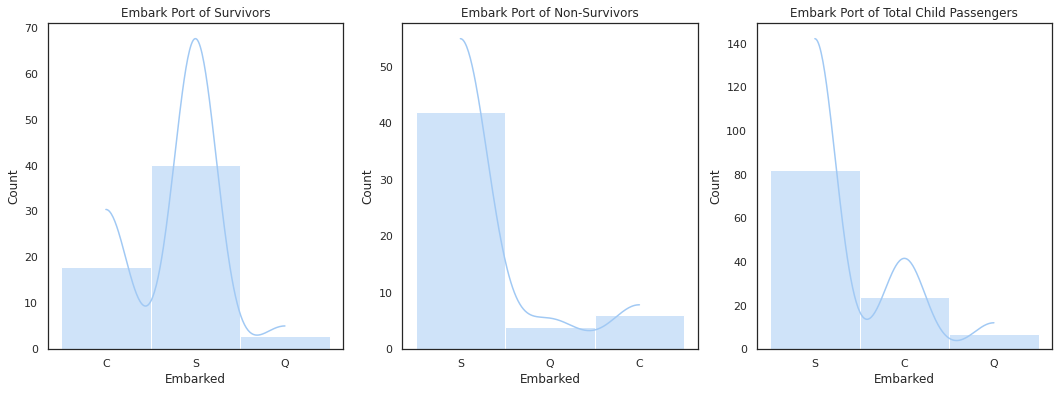

In [58]:
sns.set_theme(palette="pastel",style="white")
fig, axes = plt.subplots(1, 3)
fig.set_size_inches(18,6)
sns.histplot(df_child_survived['Embarked'],kde=True,ax=axes[0]).set_title("Embark Port of Survivors");
sns.histplot(df_child_died['Embarked'],kde=True,ax=axes[1]).set_title("Embark Port of Non-Survivors");
sns.histplot(df_child['Embarked'],kde=True,ax=axes[2]).set_title("Embark Port of Total Child Passengers");